# Trajectory Optimization in Uncertain Environments
**Sections:**
1. Imports & Setup
2. Environment Preview
3. Nominal iLQR Trajectory
4. Controller Rollouts
5. Per-Trial Animation (`@interact`)
6. Metrics Comparison Plots

---
## 1. Imports & Setup

In [3]:
import sys, os
# Make sure the project root is on the path so all packages resolve
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import jax.numpy as jnp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from ipywidgets import interact, IntSlider
%matplotlib widget

#  Environment
from environment.dynamics    import ContinuousTimeSpaceshipDynamics
from environment.integrators import RK4Integrator
from environment.asteroid_env import Asteroid, Environment
# from environment.ilqr        import (iterative_linear_quadratic_regulator,
#                                       TotalCost, rollout_state_feedback_policy)

#  Controllers
from controllers.pid           import PositionPIDController, FullStatePIDController
from controllers.state_feedback import StateFeedbackController, InfiniteHorizonLQRController
from controllers.cbf_clf_qp    import CBFCLFFilter

#  Metrics
from utils.metrics import rollout, evaluate_controller

#  Config 
from config import (
    T, dt, start_state, goal_position,
    Q, R, STATE_DIM, CONTROL_DIM
)

print('All imports OK')

ImportError: cannot import name 'Q' from 'config' (c:\Users\Adity\Documents\trajectory_optmization_ME548\trajectory_optimization\config.py)

---
## 2. Environment Preview
Scrub the slider to watch asteroids move over time.

interactive(children=(IntSlider(value=0, description='Step k', max=125), Output()), _dom_classes=('widget-inte…

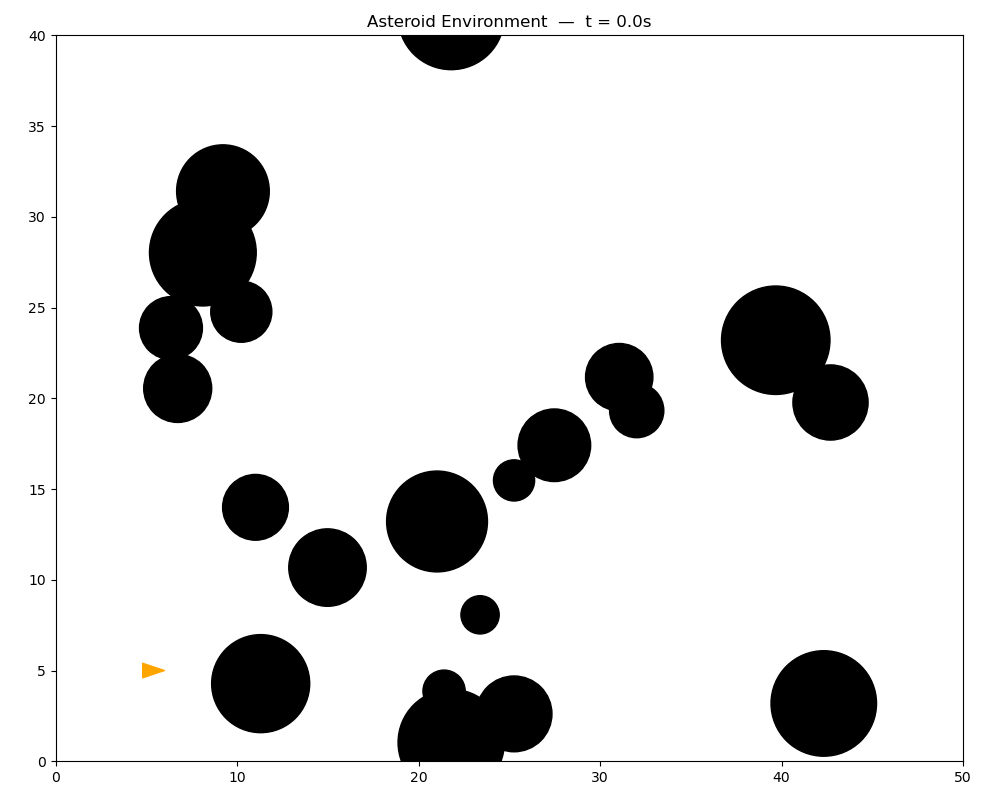

In [4]:
np.random.seed(2)
dynamics = RK4Integrator(ContinuousTimeSpaceshipDynamics(), dt)
env      = Environment.create(20)

fig_env, ax_env = env.plot(state=start_state)
ax_env.set_title('Asteroid Environment')
plt.tight_layout()

@interact(k=IntSlider(min=0, max=T, step=1, value=0, description='Step k'))
def animate_env(k=0):
    env.at_time(k * dt).plot(state=start_state, ax=ax_env)
    ax_env.set_title(f'Asteroid Environment  —  t = {k * dt:.1f}s')
    fig_env.canvas.draw_idle()

---
## 3. Nominal iLQR Trajectory
Compute the fuel-optimal reference trajectory with no obstacle awareness.
All controllers track this as their nominal path.

In [ ]:
import jax
import jax.numpy as jnp

def terminal_cost(x):
    return 1000.0 * jnp.sum((x[:2] - jnp.array(goal_position)) ** 2)

def running_cost(x, u, k):
    return 0.1 * jnp.sum(u ** 2)

total_cost = TotalCost(running_cost, terminal_cost)
u_guess    = jnp.zeros((T, CONTROL_DIM))

result  = iterative_linear_quadratic_regulator(
    dynamics, total_cost, jnp.array(start_state), u_guess
)
xs_nom, us_nom = result['optimal_trajectory']

print(f"iLQR converged in {result['num_iterations']} iterations")
print(f"Final cost : {result['optimal_cost']:.4f}")
print(f"Start : {np.array(xs_nom[0])}")
print(f"End   : {np.array(xs_nom[-1, :2])}  (target: {goal_position})")

In [ ]:
# Plot nominal trajectory on environment 
fig_nom, ax_nom = env.plot(
    state   = start_state,
    plan    = np.array(xs_nom),
    history = np.array(xs_nom),
)
ax_nom.scatter(*goal_position, s=120, marker='*', color='gold',
               zorder=20, label='Goal')
ax_nom.set_title('Nominal iLQR Trajectory (no obstacle avoidance)')
ax_nom.legend(loc='upper left')
plt.tight_layout()
plt.show()

---
## 4. Controller Rollouts
Run each controller on the same environment and store results.

In [ ]:
#  Instantiate controllers
pid_pos = PositionPIDController(
    Kp_pos=1.0, Ki_pos=0.01, Kd_pos=0.5,
    Kp_heading=2.0, Kp_speed=1.0, Kd_speed=0.3,
    r_limit=1.0, a_limit=2.0, dt=dt
)

pid_full = FullStatePIDController(
    Kp_x=1.0, Kd_x=0.5, Ki_x=0.01,
    Kp_y=1.0, Kd_y=0.5, Ki_y=0.01,
    Kp_th=2.0, Kd_th=0.3,
    Kp_vx=0.5, Kd_vx=0.1,
    Kp_vy=0.5, Kd_vy=0.1,
    r_limit=1.0, a_limit=2.0, dt=dt
)

sf_ctrl = StateFeedbackController(
    dynamics=dynamics, Q=Q, R=R,
    r_limit=1.0, a_limit=2.0
)
sf_ctrl.prepare(xs_nom, us_nom)   # compute LQR gains once

lqr_ctrl = InfiniteHorizonLQRController(
    dynamics=dynamics, Q=Q, R=R,
    r_limit=1.0, a_limit=2.0
)
lqr_ctrl.prepare(xs_nom, us_nom)  # solve DARE once

print('Controllers ready.')

Controllers ready.


In [ ]:
#  Run single rollout per controller on shared env 
controllers = {
    'PID (position)':    pid_pos,
    'PID (full-state)':  pid_full,
    'State Feedback':    sf_ctrl,
    'Inf-Horizon LQR':   lqr_ctrl,
}

controllers = {
    'PID (position)':    pid_pos,
    'PID (full-state)':  pid_full,

}

results = {}
for name, ctrl in controllers.items():
    res = rollout(
        ctrl, dynamics, xs_nom, us_nom, env,
        start_state, goal_position, T, dt
    )
    results[name] = res
    status = '✓ reached goal' if res['success'] else ('✗ collision' if res['collision'] else '✗ timeout')
    print(f"{name:22s} | {status:15s} | "
          f"track={np.mean(res['tracking_errors']):.2f} "
          f"effort={np.mean(res['control_efforts']):.2f} "
          f"time={res['traversal_time']}")

NameError: name 'xs_nom' is not defined

In [ ]:
#  Side-by-side trajectory plot 
COLORS = {
    'PID (position)':   '#e74c3c',
    'PID (full-state)': '#e67e22',
    'State Feedback':   '#2ecc71',
    'Inf-Horizon LQR':  '#3498db',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    env.plot(ax=ax,
             state   = start_state,
             plan    = np.array(xs_nom),
             history = res['history'])
    ax.plot(*res['history'][:, :2].T,
            color=COLORS[name], lw=2, label=name, zorder=15)
    ax.scatter(*goal_position, s=120, marker='*',
               color='gold', zorder=20)
    status = '✓' if res['success'] else '✗'
    ax.set_title(f'{status}  {name}', fontsize=11)
    ax.legend(fontsize=8, loc='upper left')

fig.suptitle('Controller Trajectories vs Nominal (green)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Per-Trial Animation
Scrub the slider to replay any controller's rollout step-by-step.

In [ ]:
# Pick which controller to animate
ANIMATE = 'State Feedback'

res_anim    = results[ANIMATE]
history_anim = res_anim['history']     # (T+1, 5)
controls_anim = res_anim['controls']   # (T,   2)

fig_anim, ax_anim = env.plot(
    state   = history_anim[0],
    plan    = np.array(xs_nom),
    history = history_anim[:1],
)
ax_anim.scatter(*goal_position, s=120, marker='*', color='gold', zorder=20)

@interact(k=IntSlider(min=0, max=T, step=1, value=0, description='Step k'))
def animate_rollout(k=0):
    thrust = float(np.abs(controls_anim[min(k, T-1), 1])) / 2.0  # normalise
    env.at_time(k * dt).plot(
        state         = history_anim[k],
        plan          = np.array(xs_nom),
        history       = history_anim[:k+1],
        scaled_thrust = thrust,
        sensor        = True,
        ax            = ax_anim,
    )
    track_err = float(np.linalg.norm(history_anim[k, :2] - np.array(xs_nom[k, :2])))
    ax_anim.set_title(
        f'{ANIMATE}  |  t={k*dt:.1f}s  |  '
        f'tracking error={track_err:.2f}m  |  '
        f'thrust={controls_anim[min(k,T-1),1]:.2f}'
    )
    fig_anim.canvas.draw_idle()

In [ ]:
# Tracking error and control effort over time
fig_ts, (ax_track, ax_effort) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
steps = np.arange(T) * dt

for name, res in results.items():
    ax_track.plot(steps, res['tracking_errors'],
                  color=COLORS[name], label=name, lw=1.5)
    ax_effort.plot(steps, res['control_efforts'],
                   color=COLORS[name], label=name, lw=1.5)

ax_track.set_ylabel('Tracking Error  (m)')
ax_track.set_title('Position Tracking Error over Time')
ax_track.legend()
ax_track.grid(alpha=0.3)

ax_effort.set_ylabel('Control Effort  (||u||²)')
ax_effort.set_xlabel('Time  (s)')
ax_effort.set_title('Control Effort over Time  (fuel proxy)')
ax_effort.legend()
ax_effort.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Metrics Comparison
Run 20 trials per controller and compare aggregate performance.

In [ ]:
# Multi-trial evaluation
# Re-prepare state feedback controllers before passing to evaluate_controller
# since each trial creates a fresh environment but same xs_nom/us_nom.

NUM_TRIALS    = 20
NUM_ASTEROIDS = 20

benchmark_results = {}

for name, ctrl in controllers.items():
    print(f'\nEvaluating: {name}')
    # Re-prepare LQR-based controllers (gains don't change, but reset is clean)
    if hasattr(ctrl, 'prepare'):
        ctrl.prepare(xs_nom, us_nom)
    metrics = evaluate_controller(
        ctrl, dynamics, xs_nom, us_nom,
        start_state, goal_position,
        T, dt,
        num_asteroids = NUM_ASTEROIDS,
        num_trials    = NUM_TRIALS,
        density_label = name,
        verbose       = True,
    )
    benchmark_results[name] = metrics

print('\nBenchmark complete.')

In [ ]:
# Bar chart comparison
names   = list(benchmark_results.keys())
colors  = [COLORS[n] for n in names]
x       = np.arange(len(names))
width   = 0.6

fig_bar, axes = plt.subplots(1, 4, figsize=(16, 5))

# Success rate
sr = [benchmark_results[n]['success_rate'] * 100 for n in names]
axes[0].bar(x, sr, color=colors, width=width, edgecolor='white')
axes[0].set_title('Success Rate (%)')
axes[0].set_ylim(0, 105)
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=20, ha='right', fontsize=8)
for i, v in enumerate(sr):
    axes[0].text(i, v + 1.5, f'{v:.0f}%', ha='center', fontsize=8)

# Tracking error
te_mean = [benchmark_results[n]['tracking_error_mean'] for n in names]
te_std  = [benchmark_results[n]['tracking_error_std']  for n in names]
axes[1].bar(x, te_mean, yerr=te_std, color=colors, width=width,
            edgecolor='white', capsize=4)
axes[1].set_title('Tracking Error (m)')
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=20, ha='right', fontsize=8)

# Control effort
ce_mean = [benchmark_results[n]['control_effort_mean'] for n in names]
ce_std  = [benchmark_results[n]['control_effort_std']  for n in names]
axes[2].bar(x, ce_mean, yerr=ce_std, color=colors, width=width,
            edgecolor='white', capsize=4)
axes[2].set_title('Control Effort (fuel proxy)')
axes[2].set_xticks(x); axes[2].set_xticklabels(names, rotation=20, ha='right', fontsize=8)

# Traversal time
tt_mean = [benchmark_results[n]['traversal_time_mean'] for n in names]
tt_std  = [benchmark_results[n]['traversal_time_std']  for n in names]
axes[3].bar(x, tt_mean, yerr=tt_std, color=colors, width=width,
            edgecolor='white', capsize=4)
axes[3].axhline(T, color='gray', linestyle='--', lw=1, label=f'Max steps ({T})')
axes[3].set_title('Traversal Time (steps)')
axes[3].set_xticks(x); axes[3].set_xticklabels(names, rotation=20, ha='right', fontsize=8)
axes[3].legend(fontsize=8)

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

fig_bar.suptitle(f'Controller Comparison  ({NUM_TRIALS} trials, {NUM_ASTEROIDS} asteroids)',
                 fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/controller_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/controller_comparison.png')

In [ ]:
#  Summary table
print(f'\n{"Controller":<22} {"Success":>8} {"Track Err":>12} {"Ctrl Effort":>13} {"Time":>8}')
print('-' * 67)
for name in names:
    m = benchmark_results[name]
    print(
        f'{name:<22} '
        f'{m["success_rate"]*100:>7.0f}% '
        f'{m["tracking_error_mean"]:>8.2f}±{m["tracking_error_std"]:.2f} '
        f'{m["control_effort_mean"]:>9.2f}±{m["control_effort_std"]:.2f} '
        f'{m["traversal_time_mean"]:>6.1f}±{m["traversal_time_std"]:.1f}'
    )